<a href="https://colab.research.google.com/github/i1shhd/genai-bootcamp-lab1/blob/main/W3S4_Lab_Multimodal_App_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background:linear-gradient(135deg,#16304A 0%,#003C9C 100%);border-radius:14px;padding:22px 26px;color:#fff;font-family:Segoe UI,Arial,sans-serif;">
  <div style="display:flex;justify-content:space-between;align-items:center;gap:16px;">
    <div>
      <div style="font-size:13px;letter-spacing:1px;opacity:.85;text-transform:uppercase;">Generative AI Summer Bootcamp &middot; Najran University</div>
      <div style="font-size:26px;font-weight:800;margin-top:4px;">Lab — Build, Optimize & Deploy a Multimodal App</div>
      <div style="font-size:15px;opacity:.92;margin-top:4px;">Week 3 · Session 4 — Multimodal Pipelines + NVIDIA Stack & Optimization</div>
    </div>
    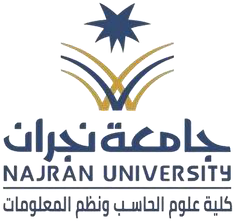
  </div>
  <div style="margin-top:16px;display:flex;gap:10px;flex-wrap:wrap;font-size:13px;">
    <span style="background:rgba(255,255,255,.16);padding:5px 12px;border-radius:20px;">🏆 NCA-GENM track</span>
    <span style="background:rgba(255,255,255,.16);padding:5px 12px;border-radius:20px;">⏱️ Lab: ≈ 45 minutes</span>
    <span style="background:rgba(255,255,255,.16);padding:5px 12px;border-radius:20px;">▶️ Runs on Google Colab (free)</span>
  </div>
</div>

<a target="_blank" href="https://colab.research.google.com/"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="border:1px solid #003C9C33;border-left:6px solid #003C9C;background:#EAF1FB;border-radius:10px;padding:16px 20px;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#003C9C;font-size:16px;margin-bottom:6px;">🎓 Learning objectives</div>
<ul style="margin:0;padding-left:20px;font-size:15px;color:#16304A;"><li style="margin:5px 0;">Chain two modalities: <b>image → caption</b> (BLIP) → <b>short story</b> (Qwen2.5).</li>
<li style="margin:5px 0;">Load the LLM in <b>4-bit</b> with bitsandbytes and compare <b>VRAM & latency</b> vs FP16.</li>
<li style="margin:5px 0;">Wrap the pipeline in a <b>Gradio</b> app and <b>make it your own</b> (your name + your story style).</li>
<li style="margin:5px 0;">Deploy your personalised app as a shareable <b>Hugging Face Space</b> to show the class.</li></ul></div>

## How to use this notebook

Run the cells **in order**, top to bottom (`Shift+Enter`). Read the short notes before each part — they connect the code back to today's slides. This is the **Week-3 capstone**: you build one small end-to-end app, make it smaller with quantization, then prepare it for deployment.

<div style="border:1px solid #16304A33;border-left:6px solid #16304A;background:#EDF1F6;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#16304A;font-size:15px;margin-bottom:4px;">🔧 First: turn on the free GPU</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">Click <b>Runtime → Change runtime type → T4 GPU → Save</b>. Quantization with bitsandbytes <b>requires a CUDA GPU</b>, so this step is mandatory today.</div></div>

### Setup
Colab already ships PyTorch. We add Transformers, bitsandbytes (quantization), accelerate, Gradio, and Pillow for images. This takes ~1–2 minutes the first time. If pip prints any red dependency warnings, you can safely ignore them.

In [1]:
# One-time setup (~1-2 minutes)
!pip -q install -U "transformers>=4.56,<6" "accelerate>=0.33" "bitsandbytes>=0.46.1" gradio "pillow==11.3.0"

# Keep the lab output clean (hides harmless library deprecation notices)
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()

print("Setup complete — now run the cells below in order.")

Setup complete — now run the cells below in order.


In [3]:
# Sanity check: confirm we are on a GPU (this lab and bitsandbytes 4-bit both need one)
import torch
print("PyTorch:", torch.__version__)
assert torch.cuda.is_available(), "No GPU! Runtime -> Change runtime type -> T4 GPU -> Save, then re-run."
print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cpu


AssertionError: No GPU! Runtime -> Change runtime type -> T4 GPU -> Save, then re-run.

## Part 1 — Modality 1: image → caption (BLIP)

Our first stage turns an **image into text**. We use `Salesforce/blip-image-captioning-base` — an open, ungated vision-language model (~1 GB). First we download a sample image.

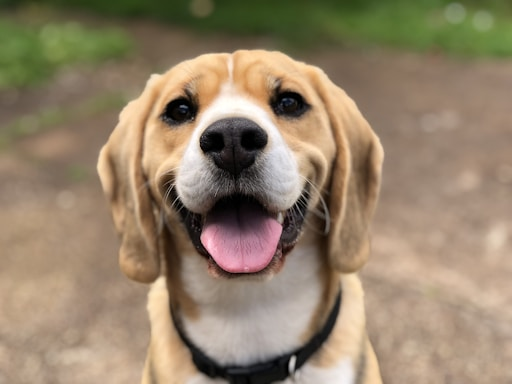

In [3]:
import requests
from io import BytesIO
from PIL import Image

# A public sample image (a dog). Replace the URL with any image you like.
url = "https://images.unsplash.com/photo-1543466835-00a7907e9de1?w=512"
image = Image.open(BytesIO(requests.get(url, timeout=15).content)).convert("RGB")
image  # Colab displays the image inline

In [4]:
from transformers import BlipProcessor, BlipForConditionalGeneration

blip_id = "Salesforce/blip-image-captioning-base"
blip_processor = BlipProcessor.from_pretrained(blip_id)
blip_model = BlipForConditionalGeneration.from_pretrained(
    blip_id, dtype=torch.float16
).to("cuda")
print("BLIP loaded.")

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

BLIP loaded.


In [5]:
def caption_image(img):
    inputs = blip_processor(img, return_tensors="pt").to("cuda", torch.float16)
    out = blip_model.generate(**inputs, max_new_tokens=30)
    return blip_processor.decode(out[0], skip_special_tokens=True)

caption = caption_image(image)
print("Caption:", caption)

Caption: a dog with its tongue out and its tongue out


<div style="border:1px solid #003C9C33;border-left:6px solid #003C9C;background:#EAF1FB;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#003C9C;font-size:15px;margin-bottom:4px;">ℹ️ This is the 'glue'</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">The caption is plain <b>text</b>. That text is exactly what we hand to the LLM in the next stage — text is the common interface that lets us chain two different models together.</div></div>

## Part 2 — Modality 2: caption → short story (Qwen2.5)

The second stage is a text LLM, `Qwen/Qwen2.5-1.5B-Instruct` (open, ungated). It takes the caption and writes a short story. We load it in **FP16** first (the Colab default).

In [6]:
from transformers import AutoTokenizer, AutoModelForCausalLM

llm_id = "Qwen/Qwen2.5-1.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(llm_id)
llm_fp16 = AutoModelForCausalLM.from_pretrained(
    llm_id,
    dtype=torch.float16,   # mixed precision: ~half the memory of FP32
    device_map="cuda",
)
print("LLM (FP16) loaded on:", next(llm_fp16.parameters()).device)

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

LLM (FP16) loaded on: cuda:0


In [7]:
def write_story(model, caption, max_new_tokens=120, style=None):
    prompt = f"Write a short, vivid 3-sentence story inspired by this image caption: '{caption}'."
    if style:
        prompt += f" Make it {style}."
    messages = [{"role": "user", "content": prompt}]
    inputs = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True,
        return_tensors="pt", return_dict=False,   # return_dict=False -> plain tensor
    ).to(model.device)
    out = model.generate(inputs, max_new_tokens=max_new_tokens,
                         do_sample=True, temperature=0.9, top_p=0.95,
                         pad_token_id=tokenizer.eos_token_id)
    return tokenizer.decode(out[0][inputs.shape[1]:], skip_special_tokens=True)

story = write_story(llm_fp16, caption)
print("CAPTION:", caption)
print("\nSTORY:\n", story)

CAPTION: a dog with its tongue out and its tongue out

STORY:
 The sun beat down on the dusty road, and a small black dog stood at attention, its tongue lolling out in a lazy yawn as it waited for something or someone to pass through the narrow path before it could begin its long journey home. The warm afternoon wind carried the sweet scent of blooming wildflowers as the dog surveyed its surroundings, lost in thought. As the sun dipped below the horizon, casting long shadows across the ground, the dog barked playfully at its owner, who was walking along the dirt trail leading back home.


<div style="border:1px solid #24783033;border-left:6px solid #247830;background:#E9F5EC;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#247830;font-size:15px;margin-bottom:4px;">💡 You just built a pipeline</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">image → <b>BLIP</b> → caption → <b>Qwen2.5</b> → story. Two models, chained by text. Because each stage is independent, you could swap BLIP for <b>Whisper</b> (audio → text) with no other change.</div></div>

<div style="border:1px solid #0C607833;border-left:6px solid #0C6078;background:#E4F1F0;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#0C6078;font-size:15px;margin-bottom:4px;">🎯 Exam tip — NCA-GENM</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">Chaining models so the <b>output of one is the input of the next</b> is the core multimodal pipeline pattern. Remember: <b>errors and latency compound</b> across stages, and all loaded models share the same GPU memory.</div></div>

## Part 3 — Optimization: 4-bit quantization vs FP16

Now the optimization the NCA-GENM **Performance Optimization** domain cares about. We measure the FP16 model's GPU memory, then reload the *same* model in **4-bit** with `bitsandbytes` and compare VRAM and latency. Let's first measure FP16. (BLIP from Part 1 is still loaded too, so both numbers below include its ~0.5 GB — the comparison between them is still fair.)

In [8]:
import time

def gpu_mem_gb():
    """Memory currently allocated on the GPU, in GB."""
    return torch.cuda.memory_allocated() / 1e9

def time_generate(model, caption, n=3):
    """Average seconds to generate a story (after one warm-up run)."""
    write_story(model, caption, max_new_tokens=60)   # warm-up
    t0 = time.time()
    for _ in range(n):
        write_story(model, caption, max_new_tokens=60)
    return (time.time() - t0) / n

fp16_mem = gpu_mem_gb()
fp16_latency = time_generate(llm_fp16, caption)
print(f"FP16  | VRAM allocated: {fp16_mem:5.2f} GB | latency: {fp16_latency:4.2f} s/story")

FP16  | VRAM allocated:  3.56 GB | latency: 2.10 s/story


### Reload the same model in 4-bit
We free the FP16 model, then load the LLM again with a `BitsAndBytesConfig`. `load_in_4bit=True` swaps the linear layers for 4-bit (NF4) layers from bitsandbytes.

In [9]:
# Free the FP16 model so we can measure the 4-bit model cleanly
import gc
del llm_fp16
gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()
print(f"VRAM after freeing FP16: {gpu_mem_gb():.2f} GB")

VRAM after freeing FP16: 0.48 GB


In [10]:
from transformers import BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,                       # 4-bit weights
    bnb_4bit_quant_type="nf4",               # NF4 = the QLoRA 4-bit type
    bnb_4bit_compute_dtype=torch.float16,    # compute in fp16
    bnb_4bit_use_double_quant=True,          # extra ~0.4 bits/param saving
)
llm_4bit = AutoModelForCausalLM.from_pretrained(
    llm_id, quantization_config=bnb_config, device_map="cuda"
)
print("LLM (4-bit) loaded.")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

LLM (4-bit) loaded.


In [11]:
# Same measurements, now in 4-bit
q4_mem = gpu_mem_gb()
q4_latency = time_generate(llm_4bit, caption)
print(f"4-bit | VRAM allocated: {q4_mem:5.2f} GB | latency: {q4_latency:4.2f} s/story")

print("\n--- Comparison ---")
print(f"VRAM:    FP16 {fp16_mem:.2f} GB  vs  4-bit {q4_mem:.2f} GB"
      f"   ->  {fp16_mem / max(q4_mem, 1e-6):.2f}x smaller")
print(f"Latency: FP16 {fp16_latency:.2f} s  vs  4-bit {q4_latency:.2f} s/story")

4-bit | VRAM allocated:  1.63 GB | latency: 17.27 s/story

--- Comparison ---
VRAM:    FP16 3.56 GB  vs  4-bit 1.63 GB   ->  2.18x smaller
Latency: FP16 2.10 s  vs  4-bit 17.27 s/story


<div style="border:1px solid #C2670D33;border-left:6px solid #C2670D;background:#FCEFE0;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#C2670D;font-size:15px;margin-bottom:4px;">⚠️ Memory down, speed not always up</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">4-bit cuts <b>VRAM</b> sharply, but on a small 1.5B model latency can be <b>similar or even higher</b> because of (de)quantization overhead. The real win of quantization is <b>fitting a bigger model</b> on the GPU you have — verify with your printed numbers above.</div></div>

In [12]:
# Confirm the pipeline still works end-to-end with the quantized model
story_4bit = write_story(llm_4bit, caption)
print("STORY (4-bit model):\n", story_4bit)

STORY (4-bit model):
 As the warm sun sets on the horizon, a playful pup's floppy ears droop in anticipation, eagerly waiting for their owner to play fetch in the backyard. In an instant, it lets out an ear-piercing bark as they leap into the air, leaping and bounding towards the yard like a rocketship, eager to chase after their toy before landing back down gently onto the porch steps.


<div style="border:1px solid #6B3FA033;border-left:6px solid #6B3FA0;background:#F1ECF8;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#6B3FA0;font-size:15px;margin-bottom:4px;">✍️ Your turn</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">Compare quality, not just speed. Generate a story from the <b>same caption</b> with the 4-bit model and judge it against the FP16 story above. Then try a different image URL from Part 1 and run the whole chain again.</div></div>

In [13]:
# 1) Generate two more stories from the 4-bit model and read them
for i in range(2):
    print(f"--- 4-bit story {i+1} ---")
    print(write_story(llm_4bit, caption))

# 2) (Optional) Try a new image: set a new URL, re-run the Part-1 caption cell,
#    then re-run this with the fresh `caption`.
# my_url = "https://images.unsplash.com/photo-1518791841217-8f162f1e1131?w=512"  # a cat

--- 4-bit story 1 ---
The fluffy brown dog's tongue flicked languidly as it lazily lounged in the sun on the sandy beach, savoring each warm, salty breeze that stirs up memories of summer days spent at the shore. As he napped under a large umbrella, his eyes closed dreamily against the heat, his tail twitching gently in response to every playful wave that splashes onto the sand. His fur glinted wetly where the waves have washed over him just moments before, reflecting the turquoise sky above in an endless cycle of light and shadow, until the world outside became one
--- 4-bit story 2 ---
In the warm sunlight filtering through the windows, Sarah leans against her cozy couch, her breath visible in the cool evening air as she contemplates the world around her, all while her loyal canine companion nuzzles into her side, its tongue lolling out like a welcoming flame in an otherwise peaceful setting, complete with gentle waves of affection cascading from their intertwined bodies.


## Part 4 — Make it yours, then wrap it in a Gradio app

A pipeline is more useful as a clickable app you can show off. `gradio` turns one Python function into a web UI. First, **make this app yours**: put your name on it and choose the *vibe* of the stories it tells. Then launch it — everyone's app will be different.

In [14]:
# ✍️  MAKE IT YOURS — edit these two lines, then run this cell.
YOUR_NAME   = "Yazeed"                    # your name goes on the app title
STORY_STYLE = "an epic fantasy saga"      # the vibe of every story your app writes
# Try any vibe you like, for example:
#   "a funny bedtime story for kids"    ·  "a spooky ghost story"
#   "a haiku"                           ·  "a dramatic movie-trailer voiceover"
#   "a traditional Arabian Nights tale" ·  "a hard-boiled detective scene"

# Preview your style on the caption from Part 1:
print(f"~ {YOUR_NAME}'s Storyteller · style: {STORY_STYLE} ~\n")
print(write_story(llm_4bit, caption, style=STORY_STYLE))

~ Yazeed's Storyteller · style: an epic fantasy saga ~

In the grand realm of Eldoria, where dragons soar and unicorns dance in feathery grace, there lived a young warrior named Elara. One stormy night, under a sky painted crimson and silver, Elara witnessed a vision that would shape her destiny — the very essence of her soul was being drawn from her heart into the void below, carrying the promise of eternal glory to the highest realms. Her courage swelled within as she gazed upon the horizon, ready for whatever adventure lay ahead, certain that this journey would be one filled with wonders beyond imagination, leading the way through ancient


In [15]:
import gradio as gr

def multimodal_app(input_image):
    if input_image is None:
        return "Please upload an image.", ""
    cap = caption_image(input_image.convert("RGB"))
    story = write_story(llm_4bit, cap, style=STORY_STYLE)
    return cap, story

demo = gr.Interface(
    fn=multimodal_app,
    inputs=gr.Image(type="pil", label="Upload an image"),
    outputs=[gr.Textbox(label="Caption (BLIP)"),
             gr.Textbox(label=f"Your story ({STORY_STYLE})")],
    title=f"{YOUR_NAME}'s Image Storyteller",
    description=f"Upload any photo — BLIP captions it, then Qwen2.5 turns it into {STORY_STYLE}.",
)
demo.launch(share=True)   # share=True gives a temporary public URL

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2244a83005fad4477a.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


<div style="border:1px solid #24783033;border-left:6px solid #247830;background:#E9F5EC;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#247830;font-size:15px;margin-bottom:4px;">💡 Try it — and show a friend</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">Click the public <b>gradio.live</b> link (or use the inline panel), upload any image, and watch <b>your</b> storyteller work. That gradio.live link is live for ~72 hours — send it to a classmate to try. Press the stop button on the cell when you are done to free the app.</div></div>

## Part 5 — Deploy your app to a Hugging Face Space

A `share=True` link is temporary. To publish **your** app permanently and for free, push two files to a **Hugging Face Space** (Gradio SDK). The cell below writes those files — already personalised with your name and story style from Part 4 — for you to download.

In [16]:
app_py = '''import gradio as gr
import torch
from PIL import Image
from transformers import (BlipProcessor, BlipForConditionalGeneration,
                          AutoTokenizer, AutoModelForCausalLM)

APP_TITLE   = "__YOUR_NAME__ — Image Storyteller"
STORY_STYLE = "__STORY_STYLE__"

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

blip_id = "Salesforce/blip-image-captioning-base"
blip_processor = BlipProcessor.from_pretrained(blip_id)
blip_model = BlipForConditionalGeneration.from_pretrained(blip_id, dtype=dtype).to(device)

llm_id = "Qwen/Qwen2.5-1.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(llm_id)
llm = AutoModelForCausalLM.from_pretrained(llm_id, dtype=dtype).to(device)

def caption_image(img):
    inputs = blip_processor(img, return_tensors="pt").to(device, dtype)
    out = blip_model.generate(**inputs, max_new_tokens=30)
    return blip_processor.decode(out[0], skip_special_tokens=True)

def write_story(caption):
    prompt = f"Write a short, vivid 3-sentence story inspired by: \'{caption}\'. Make it {STORY_STYLE}."
    messages = [{"role": "user", "content": prompt}]
    inputs = tokenizer.apply_chat_template(messages, add_generation_prompt=True,
                                           return_tensors="pt", return_dict=False).to(device)
    out = llm.generate(inputs, max_new_tokens=120, do_sample=True, temperature=0.9,
                       top_p=0.95, pad_token_id=tokenizer.eos_token_id)
    return tokenizer.decode(out[0][inputs.shape[1]:], skip_special_tokens=True)

def app(img):
    if img is None:
        return "Please upload an image.", ""
    cap = caption_image(img.convert("RGB"))
    return cap, write_story(cap)

gr.Interface(
    fn=app,
    inputs=gr.Image(type="pil", label="Upload an image"),
    outputs=[gr.Textbox(label="Caption"), gr.Textbox(label="Story")],
    title=APP_TITLE,
    description=f"Upload a photo — it gets captioned, then turned into {STORY_STYLE}.",
).launch()
'''

# Bake in your name and style from Part 4 so the deployed app matches:
app_py = app_py.replace("__YOUR_NAME__", YOUR_NAME).replace("__STORY_STYLE__", STORY_STYLE)

requirements = "transformers>=4.56,<6\\naccelerate>=0.33\\ntorch\\npillow==11.3.0\\ngradio"

with open("app.py", "w") as f:
    f.write(app_py)
with open("requirements.txt", "w") as f:
    f.write(requirements)

print("Wrote app.py and requirements.txt")
print("Files in this Colab session — download them from the left Files panel.")

Wrote app.py and requirements.txt
Files in this Colab session — download them from the left Files panel.


<div style="border:1px solid #003C9C33;border-left:6px solid #003C9C;background:#EAF1FB;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#003C9C;font-size:15px;margin-bottom:4px;">ℹ️ Publish in 4 steps (no code)</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">0) You need a free <b>huggingface.co</b> account (sign up if you haven't already).  1) Go to <b>huggingface.co/new-space</b> and pick the <b>Gradio</b> SDK.  2) Upload the <b>app.py</b> and <b>requirements.txt</b> this cell created.  3) The Space builds automatically and gives you a public URL.  4) (Optional) Push the same files to your <b>genai-bootcamp-lab1</b> GitHub repo to version them.</div></div>

<div style="border:1px solid #C2670D33;border-left:6px solid #C2670D;background:#FCEFE0;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#C2670D;font-size:15px;margin-bottom:4px;">⚠️ Free Spaces run on CPU</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">The default free Space hardware is <b>CPU</b>, so the app.py above loads models in fp32/fp16 on CPU (slower but free). For GPU + 4-bit serving you would select paid GPU hardware and add a <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">BitsAndBytesConfig</code> — the same code you ran in Part 3.</div></div>

<div style="border:1px solid #24783033;border-left:6px solid #247830;background:#E9F5EC;border-radius:10px;padding:16px 20px;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#247830;font-size:16px;margin-bottom:6px;">✅ Recap &amp; exam-readiness check</div>
<ul style="margin:0;padding-left:20px;font-size:15px;"><li style="margin:5px 0;">A multimodal app = <b>chained models</b> with <b>text as the glue</b> (image → caption → story).</li>
<li style="margin:5px 0;">Each stage is independent — you can swap BLIP for <b>Whisper</b> without touching the LLM.</li>
<li style="margin:5px 0;"><b>FP16</b> halves memory vs FP32; <b>4-bit</b> (bitsandbytes NF4) cuts it much further.</li>
<li style="margin:5px 0;">Quantization saves <b>VRAM</b>; on small models it does <b>not</b> always reduce latency — measure it.</li>
<li style="margin:5px 0;"><b>NeMo</b> builds, <b>TensorRT/CUDA</b> accelerate, <b>Triton</b> serves — the production stack.</li>
<li style="margin:5px 0;"><b>Gradio + Hugging Face Spaces</b> takes a Colab pipeline to a public app, for free.</li></ul></div>

---
### 🎉 You built something — now share it
You have **your own** image storyteller: a live, public app with your name on it that turns any photo into *your* chosen style of story. No two students' apps are the same. To finish:

- **Deploy it** as a Space (Part 5) and **share your Space URL** with the class.
- Commit this notebook and your `app.py` / `requirements.txt` to your **`genai-bootcamp-lab1`** GitHub repo (`File → Save a copy in GitHub`).

This is the **Week-3 capstone**. Next week you design and build a GenAI app entirely your own.